# **Moirai**

D8 solutions

As a baseline, the current collision-parts forecast (using the generic model) has a WMAPE of around 70% using a 2-month lag and a 3-month rolling average.

Forecast requirements:

- Granularity: Provide monthly forecasts at the SKU level, for the defined collision parts scope.
- Horizon: Forecast 18 months ahead, updated monthly.
- Accuracy metric: Use WMAPE, assessed with:
  - 3-month forecast lag (forecasts are judged against actuals two months later)
  - 3-month rolling average of WMAPE (to smooth month-to-month noise)
- Benchmarking: Compare results against the current baseline model, with improvement reported in WMAPE points and %.
- Backtesting: Use a rolling-origin backtest that matches the real operating cadence (train on history, predict forward with the 3-month lag).
- Edge cases: Be explicit about how you handle:
  - Zero-demand months (common in collision parts)
  - New / discontinued / superseded SKUs
- Outputs: Provide forecasts plus a short explanation of what drives performance (where it works well, where it struggles, and why) and provide the meaning of the features used.

In [1]:
!pip uninstall -y torchvision -q

!pip install -q \
    "torchvision==0.19.1" \
    uni2ts \
    gluonts \
    huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 116.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 141.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [41]:
# Restart runtime before downloading libaries, for compatibility purposes

import numpy as np
import pandas as pd
import torch
import torchvision
import uni2ts
import gluonts

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("uni2ts:", uni2ts.__version__)
print("gluonts:", gluonts.__version__)

numpy: 1.26.4
pandas: 2.1.4
torch: 2.4.1+cu121
torchvision: 0.19.1+cu121
uni2ts: 2.0.0
gluonts: 0.14.4


In [42]:
from uni2ts.model.moirai2 import (
    Moirai2Forecast,
    Moirai2Module,
)

print("Moirai 2 imported successfully!")

Moirai 2 imported successfully!


In [43]:
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

In [78]:
# Load data

spreadsheet_id = "1QX9PieVqefPa7A9R99q7BSSUl36Dqm66nn9oEb8iMZY"
gid = "1717943535"

url = f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv&gid={gid}"

sales_collision = pd.read_csv(url)

sales_collision.head()

,ts_id,Date,REVENUE,COST,UNIT_PRICE,TOTAL_PROFIT,UNIT_COST,STOCK_END_MONTH,STOCK_START_MONTH,NEW_ENTRY_STOCK,...,CURRENCY,value,collision_flag,sku_id,date,demand,collision_flag_clean,is_collision,month,demand_type
0,083144012A000,2024-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,JPY,0,COLLISION,083144012A000,2024-08-01,0,COLLISION,True,2024-08-01,Intermittent
1,09148M06022000,2025-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,USD,0,COLLISION,09148M06022000,2025-01-01,0,COLLISION,True,2025-01-01,Intermittent
2,926225187000,2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,JPY,0,COLLISION,926225187000,2025-10-01,0,COLLISION,True,2025-10-01,Intermittent
3,928044008000,2024-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,JPY,0,COLLISION,928044008000,2024-06-01,0,COLLISION,True,2024-06-01,Intermittent
4,928044008000,2024-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,JPY,0,COLLISION,928044008000,2024-12-01,0,COLLISION,True,2024-12-01,Intermittent


In [79]:
print(f"SKUs               : {df['sku_id'].nunique():,}")
print(f"Months             : {df['month'].nunique()}")
print(f"Rows               : {len(df):,}")

print()

print(df.groupby("demand_type")["sku_id"].nunique())

SKUs               : 8,097
Months             : 28
Rows               : 180,422

demand_type
Erratic                124
Intermittent          6593
Lumpy                  381
No demand observed      27
Smooth                 972
Name: sku_id, dtype: int64


In [80]:
# SKU Metadata

sku_meta = (
    df.groupby("sku_id", as_index=False)
      .agg(total_demand_sku=("demand", "sum"))
)

# Top 20%
top20 = sku_meta["total_demand_sku"].quantile(0.80)
sku_meta["is_top20pct"] = (
    sku_meta["total_demand_sku"] >= top20
).astype(int)

# Top 5%
top5 = sku_meta["total_demand_sku"].quantile(0.95)
sku_meta["is_top5pct"] = (
    sku_meta["total_demand_sku"] >= top5
).astype(int)

display(sku_meta.head())

,sku_id,total_demand_sku,is_top20pct,is_top5pct
0,015500612A000,8,0,0
1,01550M0612A,2,0,0
2,01550M0835A000,1,0,0
3,015511025A000,11,0,0
4,021420412A000,2,0,0


In [81]:
FORECAST_LAG = 3
N_FORECAST = 18
MIN_TRAIN = 24

DEMAND_TYPES = [
    "Lumpy",
    "Intermittent",
    "Erratic",
    "Smooth"
]

In [82]:
# WMAPE

def wmape(actual, forecast):

    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)

    if actual.sum() == 0:
        return np.nan

    return (
        np.abs(actual - forecast).sum()
        / actual.sum()
    )

In [83]:
# Baseline

def baseline_wmape(data):

    d = (
        data
        .sort_values(
            ["sku_id", "month"]
        )
        .copy()
    )

    d["baseline"] = (
        d.groupby("sku_id")["demand"]
        .transform(
            lambda x:
            x.shift(FORECAST_LAG)
            .rolling(
                3,
                min_periods=1
            )
            .mean()
        )
    )

    valid = d.dropna(
        subset=["baseline"]
    )

    return wmape(
        valid["demand"],
        valid["baseline"]
    )

In [84]:
# Load Moirai2

model = Moirai2Forecast(
    module=Moirai2Module.from_pretrained(
        "Salesforce/moirai-2.0-R-small"
    ),
    prediction_length=N_FORECAST,
    context_length=MIN_TRAIN,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

print("Moirai loaded successfully.")

Moirai loaded successfully.


In [85]:
# Moirai Forecast Function
# We use the median quantile

def moirai_forecast(history):
    history = history.astype(np.float32)
    forecast = model.predict(
        past_target=[history]
    )
    median_forecast = forecast[
        0,
        4,
        :
    ]

    return median_forecast

In [86]:
sku = df["sku_id"].iloc[0]

history = (

    df[df["sku_id"] == sku]

    .sort_values("month")

    ["demand"]

    .values

)

fc = moirai_forecast(history)

print(fc.shape)

print(fc)

(18,)
[0.00666597 0.01083004 0.00944927 0.01389298 0.01356393 0.0123612
 0.00874698 0.00613061 0.01016375 0.0065929  0.00950786 0.00678113
 0.01023155 0.00954589 0.01058042 0.0091643  0.0076862  0.00725529]


In [87]:
# Rolling-Origin Backtest

def rolling_backtest(data):

    results = []

    for sku in data["sku_id"].unique():
        sku_df = (
            data[data["sku_id"] == sku]
            .sort_values("month")
            .reset_index(drop=True)
        )

        # Require enough history
        if len(sku_df) < (MIN_TRAIN + FORECAST_LAG):
            continue

        for origin in range(
            MIN_TRAIN,
            len(sku_df) - FORECAST_LAG + 1
        ):

            history = (
                sku_df
                .iloc[:origin]["demand"]
                .values
                .astype(np.float32)
            )

            try:
                forecast = moirai_forecast(history)

            except Exception:
                continue

            results.append({
                "sku_id":
                    sku,
                "cutoff":
                    sku_df.iloc[origin - 1]["month"],
                "pred_month":
                    sku_df.iloc[
                        origin + FORECAST_LAG - 1
                    ]["month"],
                "actual":
                    sku_df.iloc[
                        origin + FORECAST_LAG - 1
                    ]["demand"],
                "forecast":
                    max(
                        0,
                        forecast[
                            FORECAST_LAG - 1
                        ]
                    )
            })

    results = pd.DataFrame(results)

    print(f"Generated {len(results):,} forecasts")

    return results

In [88]:
# Evaluate by Demand Type

summary_rows = []

backtests = {}

for dt in DEMAND_TYPES:

    subset = (
        df[df["demand_type"] == dt]
        .copy()
    )

    print()
    print("=" * 60)
    print(dt)
    print("=" * 60)

    baseline = baseline_wmape(subset)

    bt = rolling_backtest(subset)

    if len(bt) == 0:
        print("No valid forecasts.")
        continue

    monthly = (
        bt
        .groupby("pred_month")
        .apply(
            lambda g:
            wmape(
                g["actual"],
                g["forecast"]
            )
        )
        .rename("wmape")
        .reset_index()
    )

    monthly["rolling_wmape"] = (
        monthly["wmape"]
        .rolling(
            3,
            min_periods=1
        )
        .mean()
    )

    moirai_wmape = (
        monthly["rolling_wmape"]
        .mean()
    )

    improvement = baseline - moirai_wmape

    print(f"Baseline : {baseline:.4f}")
    print(f"Moirai   : {moirai_wmape:.4f}")
    print(f"Improvement : {improvement:+.4f}")

    backtests[dt] = bt

    summary_rows.append({
        "demand_type":
            dt,
        "baseline_wmape":
            baseline,
        "moirai_wmape":
            moirai_wmape,
        "improvement_pts":
            improvement,
        "improvement_pct":
            improvement / baseline * 100

    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)


Lumpy
Generated 322 forecasts
Baseline : 1.3597
Moirai   : 0.9029
Improvement : +0.4568

Intermittent
Generated 3,591 forecasts
Baseline : 1.4436
Moirai   : 0.9933
Improvement : +0.4503

Erratic
Generated 180 forecasts
Baseline : 0.7635
Moirai   : 0.6626
Improvement : +0.1009

Smooth
Generated 1,712 forecasts
Baseline : 0.4663
Moirai   : 0.5383
Improvement : -0.0720


,demand_type,baseline_wmape,moirai_wmape,improvement_pts,improvement_pct
0,Lumpy,1.359658,0.902861,0.456797,33.596443
1,Intermittent,1.443602,0.993303,0.450299,31.192729
2,Erratic,0.763544,0.662613,0.100931,13.218748
3,Smooth,0.466297,0.538309,-0.072012,-15.443433


In [89]:
# Generate 18-Month Forecasts

forecast_parts = []

for dt in DEMAND_TYPES:
    print(f"\nForecasting {dt}...")
    subset = df[df["demand_type"] == dt]
    for sku in subset["sku_id"].unique():
        sku_df = (
            subset[subset["sku_id"] == sku]
            .sort_values("month")
            .reset_index(drop=True)
        )

        # Require sufficient history
        if len(sku_df) < MIN_TRAIN:
            continue

        history = (
            sku_df["demand"]
            .values
            .astype(np.float32)
        )

        try:
            forecast = moirai_forecast(history)

        except Exception:
            continue

        future_months = pd.date_range(
            start=sku_df["month"].max() + pd.DateOffset(months=1),
            periods=N_FORECAST,
            freq="MS"
        )

        temp = pd.DataFrame({
            "sku_id": sku,
            "month": future_months,
            "forecast": np.maximum(forecast, 0),
            "demand_type": dt
        })

        forecast_parts.append(temp)

forecasts_18m = pd.concat(
    forecast_parts,
    ignore_index=True
)

forecasts_18m["horizon"] = (
    forecasts_18m
    .groupby("sku_id")
    .cumcount()
    + 1
)

print("\nForecast complete.")
print(f"{forecasts_18m['sku_id'].nunique():,} SKUs")
print(f"{len(forecasts_18m):,} forecast rows")

display(forecasts_18m.head())


Forecasting Lumpy...

Forecasting Intermittent...

Forecasting Erratic...

Forecasting Smooth...

Forecast complete.
4,788 SKUs
86,184 forecast rows


,sku_id,month,forecast,demand_type,horizon
0,015500612A000,2026-05-01,0.006666,Lumpy,1
1,015500612A000,2026-06-01,0.010830,Lumpy,2
2,015500612A000,2026-07-01,0.009449,Lumpy,3
3,015500612A000,2026-08-01,0.013893,Lumpy,4
4,015500612A000,2026-09-01,0.013564,Lumpy,5


In [90]:
# Historical Predictions

insample_parts = []

for dt in DEMAND_TYPES:
    bt = backtests[dt].copy()
    temp = bt.rename(
        columns={
            "forecast": "moirai_insample"
        }
    )
    insample_parts.append(
        temp[
            [
                "sku_id",
                "pred_month",
                "moirai_insample"
            ]
        ]
    )

insample_df = pd.concat(
    insample_parts,
    ignore_index=True
)

insample_df = insample_df.rename(
    columns={
        "pred_month": "month"
    }
)

print(insample_df.shape)

display(insample_df.head())

(5805, 3)


,sku_id,month,moirai_insample
0,09403M07311000,2026-03-01,0.335688
1,09403M07311000,2026-04-01,0.233291
2,09409M10L04000,2026-03-01,4.663870
3,09409M10L04000,2026-04-01,7.595022
4,09409M15L01000,2026-03-01,2.114904


In [91]:
# Combine All Backtest Predictions

backtest_df = pd.concat(
    backtests.values(),
    ignore_index=True
)

print(backtest_df.shape)

display(backtest_df.head())

(5805, 5)


,sku_id,cutoff,pred_month,actual,forecast
0,09403M07311000,2025-12-01,2026-03-01,0,0.335688
1,09403M07311000,2026-01-01,2026-04-01,1,0.233291
2,09409M10L04000,2025-12-01,2026-03-01,31,4.663870
3,09409M10L04000,2026-01-01,2026-04-01,13,7.595022
4,09409M15L01000,2025-12-01,2026-03-01,0,2.114904


In [92]:
# SKU-Level WMAPE

sku_meta = (
    df[
        [
            "sku_id",
            "demand_type"
        ]
    ]
    .drop_duplicates()
)

sku_wmape = (
    backtest_df
    .groupby("sku_id")
    .apply(
        lambda g:
        pd.Series({
            "moirai_wmape":
                wmape(
                    g["actual"],
                    g["forecast"]
                ),
            "total_demand":
                g["actual"].sum()
        })
    )
    .reset_index()
)

sku_wmape = sku_wmape.merge(
    sku_meta,
    on="sku_id",
    how="left"
)

In [93]:
# Baseline WMAPE Per SKU

baseline_df = (
    df
    .sort_values(
        [
            "sku_id",
            "month"
        ]
    )
    .copy()
)

baseline_df["baseline"] = (
    baseline_df
    .groupby("sku_id")["demand"]
    .transform(
        lambda x:
        x.shift(FORECAST_LAG)
        .rolling(
            3,
            min_periods=1
        )
        .mean()
    )
)

baseline_df = baseline_df.dropna(
    subset=["baseline"]
)

baseline_sku = (
    baseline_df
    .groupby("sku_id")
    .apply(
        lambda g:
        wmape(
            g["demand"],
            g["baseline"]
        )
    )
    .rename("baseline_wmape")
    .reset_index()
)

sku_wmape = sku_wmape.merge(
    baseline_sku,
    on="sku_id"
)

In [96]:
# Improvement Analysis

# Percentage improvement over the baseline
sku_wmape["improvement_pct"] = (
    (
        sku_wmape["baseline_wmape"]
        -
        sku_wmape["moirai_wmape"]
    )
    /
    sku_wmape["baseline_wmape"]
    * 100
)

# Add SKU metadata

sku_wmape = sku_wmape.merge(
    sku_meta,
    on="sku_id",
    how="left"
)

# SKUs improved by more than 10%

improved = (
    sku_wmape[
        sku_wmape["improvement_pct"] > 10
    ]
    .sort_values(
        "total_demand",
        ascending=False
    )
    .reset_index(drop=True)
)

print(f"{len(improved):,} SKUs improved by >10%")

display(
    improved[
        [
            "sku_id",
            "demand_type",
            "total_demand",
            "total_demand_sku",
            "is_top20pct",
            "is_top5pct",
            "baseline_wmape",
            "moirai_wmape",
            "improvement_pct"
        ]
    ]
    .head(20)
)

1,281 SKUs improved by >10%


,sku_id,demand_type,total_demand,total_demand_sku,is_top20pct,is_top5pct,baseline_wmape,moirai_wmape,improvement_pct
0,09409M08006000,Erratic,289.0,3193,1,1,0.790963,0.466269,41.050553
1,911912012000,Smooth,100.0,1105,1,1,0.489763,0.312986,36.094465
2,09409M15L01000,Lumpy,95.0,302,1,1,1.228039,1.018089,17.096369
3,71711M55T00799,Smooth,82.0,782,1,1,0.449030,0.181537,59.571230
4,72421M68P01000,Smooth,74.0,1043,1,1,0.203624,0.118062,42.019396
5,17700M68P00000,Smooth,65.0,945,1,1,0.207570,0.173983,16.181046
6,71740M68T00C48,Smooth,61.0,859,1,1,0.260722,0.046951,81.991880
7,72460M68P10000,Smooth,58.0,718,1,1,0.220924,0.104417,52.736227
8,71731M55R00000,Smooth,57.0,756,1,1,0.280225,0.166964,40.417992
9,71711M55R00799,Smooth,51.0,788,1,1,0.212707,0.139202,34.556768


In [97]:
total_skus = improved["sku_id"].nunique()

for col, label in [
    ("is_top20pct", "Top 20%"),
    ("is_top5pct", "Top 5%"),
]:

    counts = improved[col].value_counts()

    pct_of_improved = (
        counts / total_skus * 100
    ).round(1)

    total_in_tier = (
        sku_meta[sku_meta[col] == 1]
        .shape[0]
    )

    improved_in_tier = (
        improved[improved[col] == 1]
        .shape[0]
    )

    pct_of_tier = round(
        improved_in_tier /
        total_in_tier *
        100,
        1
    )

    print(f"\n{label}")

    print(
        pd.DataFrame({
            "count": counts,
            "pct_of_improved": pct_of_improved
        })
    )

    print(
        f"{improved_in_tier} of {total_in_tier} "
        f"({pct_of_tier}%)"
    )


Top 20%
             count  pct_of_improved
is_top20pct                        
1              752             58.7
0              529             41.3
752 of 1635 (46.0%)

Top 5%
            count  pct_of_improved
is_top5pct                        
0            1078             84.2
1             203             15.8
203 of 405 (50.1%)


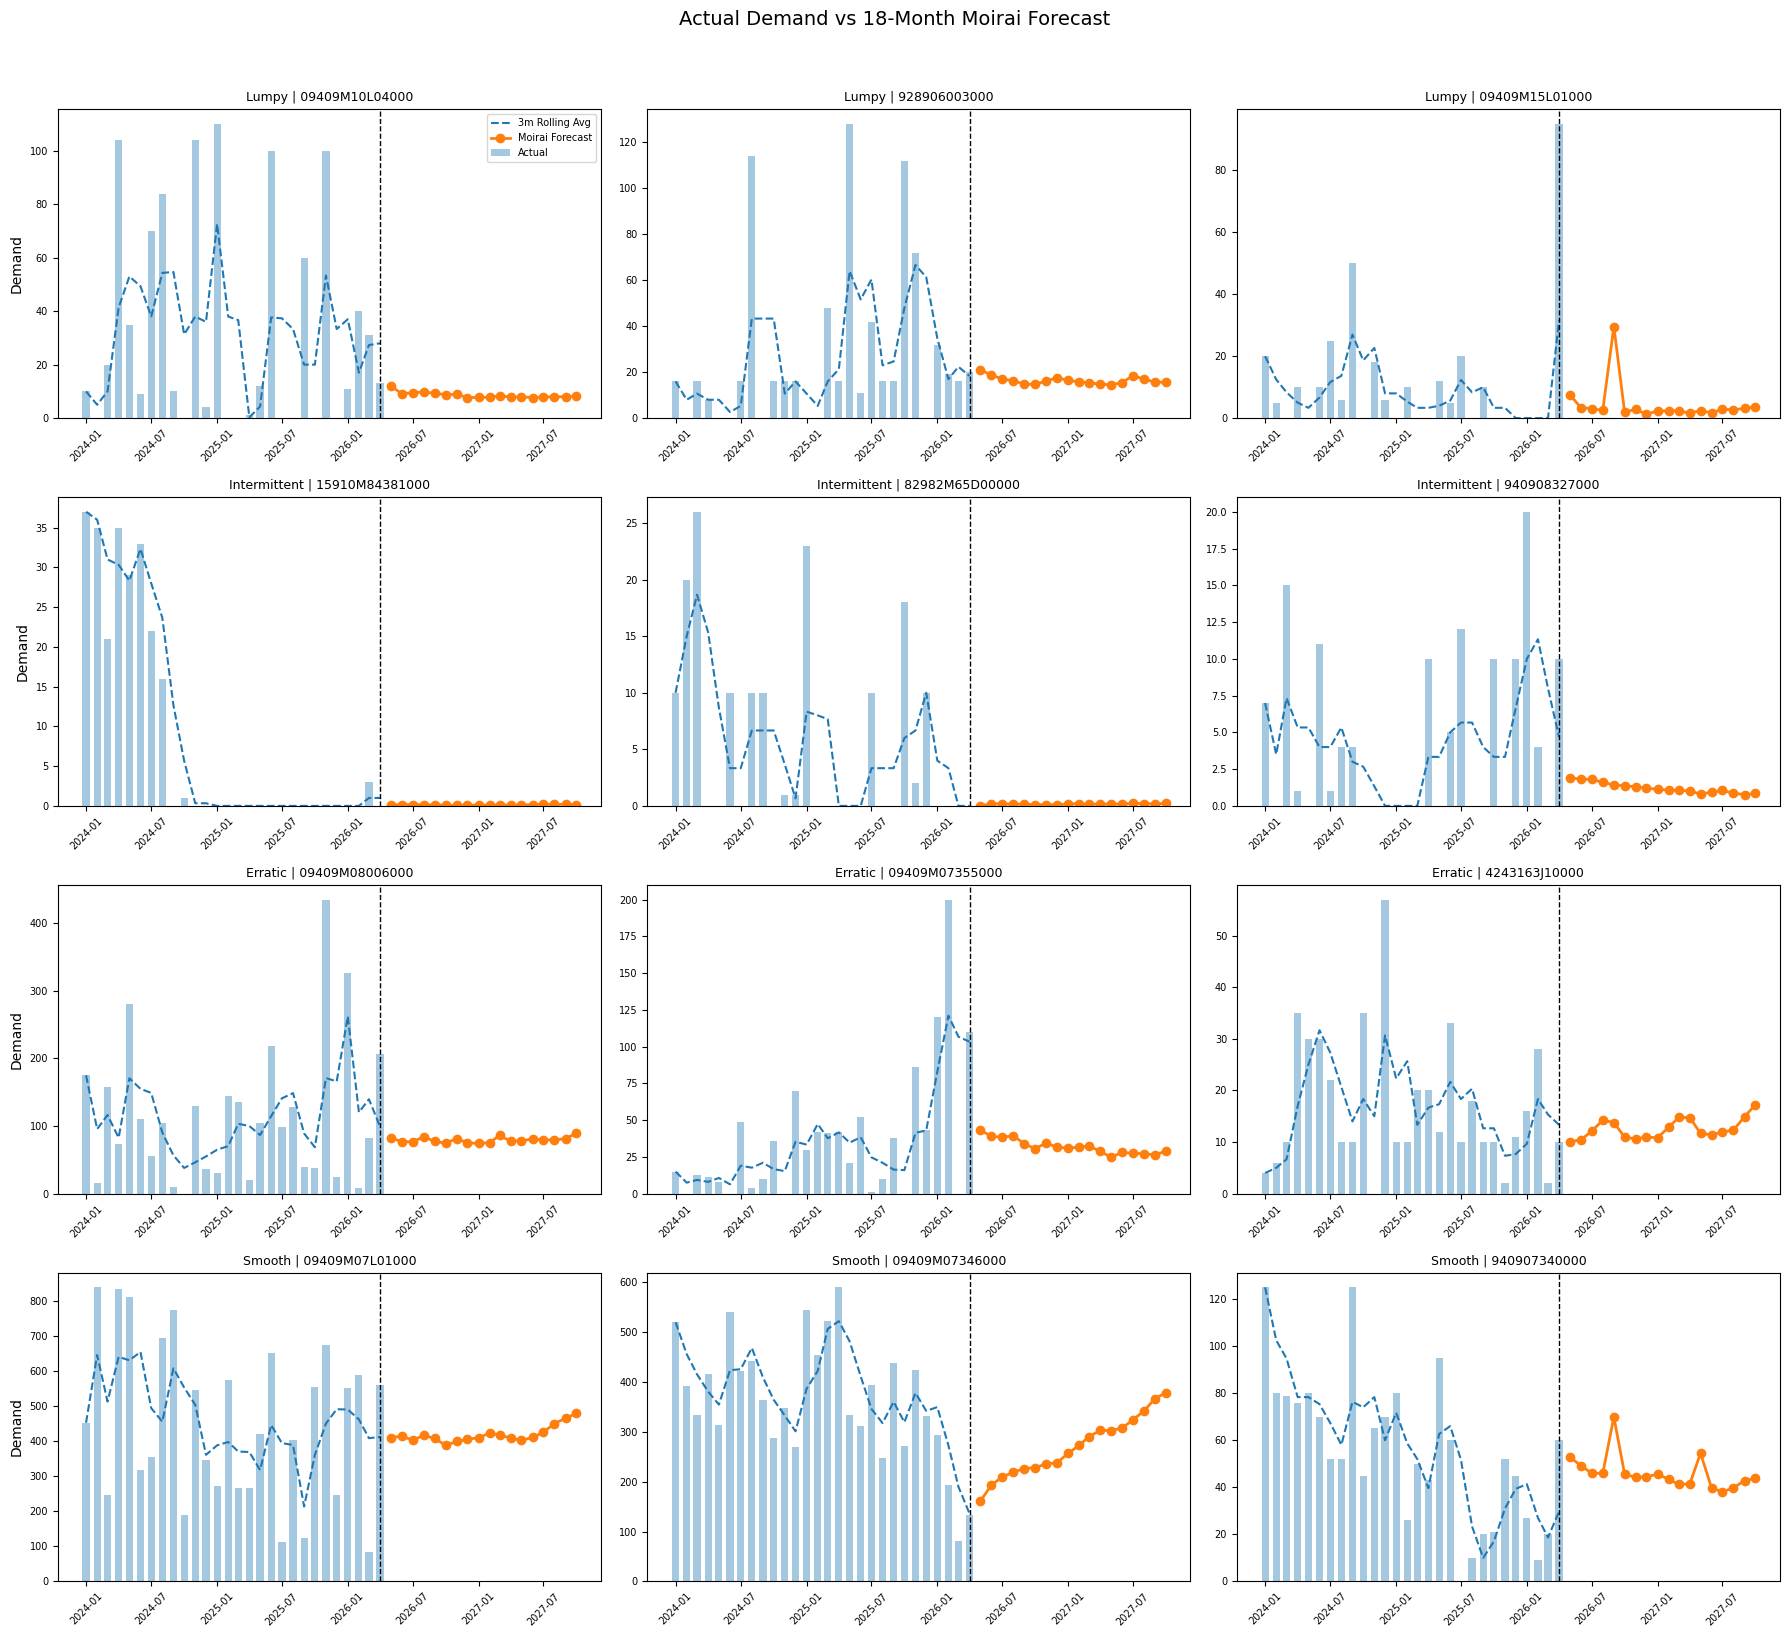

In [100]:
# Visualise Forecasts

import matplotlib.pyplot as plt

N_SKUS_PER_TYPE = 3

fig_rows = len(DEMAND_TYPES)

fig, axes = plt.subplots(
    fig_rows,
    N_SKUS_PER_TYPE,
    figsize=(18, fig_rows * 4)
)

fig.suptitle(
    "Actual Demand vs 18-Month Moirai Forecast",
    fontsize=14,
    y=1.02
)

# Handle the case where there's only one demand type
if fig_rows == 1:
    axes = np.array([axes])

for row_idx, dt in enumerate(DEMAND_TYPES):
    top_skus = (
        df[df["demand_type"] == dt]
        .groupby("sku_id")["demand"]
        .sum()
        .nlargest(N_SKUS_PER_TYPE)
        .index
    )

    for col_idx, sku in enumerate(top_skus):
        ax = axes[row_idx][col_idx]

        # Historical demand

        actual = (
            df[df["sku_id"] == sku]
            [["month", "demand"]]
            .sort_values("month")
        )

        actual["rolling_avg"] = (
            actual["demand"]
            .rolling(
                3,
                min_periods=1
            )
            .mean()
        )

        # Future forecast

        future = (
            forecasts_18m[
                forecasts_18m["sku_id"] == sku
            ]
            .sort_values("month")
        )

        ax.bar(
            actual["month"],
            actual["demand"],
            alpha=0.40,
            width=20,
            label="Actual"
        )

        ax.plot(
            actual["month"],
            actual["rolling_avg"],
            linestyle="--",
            linewidth=1.5,
            label="3m Rolling Avg"
        )

        ax.plot(
            future["month"],
            future["forecast"],
            marker="o",
            linewidth=2,
            label="Moirai Forecast"
        )

        ax.axvline(
            actual["month"].max(),
            linestyle="--",
            linewidth=1,
            color="black"
        )

        ax.set_title(
            f"{dt} | {sku}",
            fontsize=9
        )

        ax.tick_params(
            axis="x",
            rotation=45,
            labelsize=7
        )

        ax.tick_params(
            axis="y",
            labelsize=7
        )

        if col_idx == 0:
            ax.set_ylabel("Demand")

        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7)

plt.tight_layout()

plt.show()

In [105]:
# Save Forecasts

forecasts_18m.to_csv(
    "moirai_forecasts_18m.csv",
    index=False
)

print("Saved - moirai_forecasts_18m.csv")

Saved - moirai_forecasts_18m.csv


In [102]:
# WMAPE Distribution

bins = [
    0,
    0.3,
    0.5,
    0.7,
    1.0,
    1.5,
    2.0,
    float("inf")
]

labels = [
    "<30%",
    "30-50%",
    "50-70%",
    "70-100%",
    "100-150%",
    "150-200%",
    ">200%"
]

sku_wmape["wmape_band"] = pd.cut(
    sku_wmape["moirai_wmape"],
    bins=bins,
    labels=labels
)

band_counts = (
    sku_wmape["wmape_band"]
    .value_counts()
    .sort_index()
)

band_pct = (
    band_counts
    / len(sku_wmape)
    * 100
).round(1)

print("Distribution of SKU-level Moirai WMAPE")

display(

    pd.DataFrame({

        "n_skus": band_counts,

        "pct_of_skus": band_pct

    })

)

Distribution of SKU-level Moirai WMAPE


,n_skus,pct_of_skus
wmape_band,,
<30%,278,8.3
30-50%,315,9.4
50-70%,303,9.1
70-100%,647,19.4
100-150%,343,10.3
150-200%,38,1.1
>200%,48,1.4


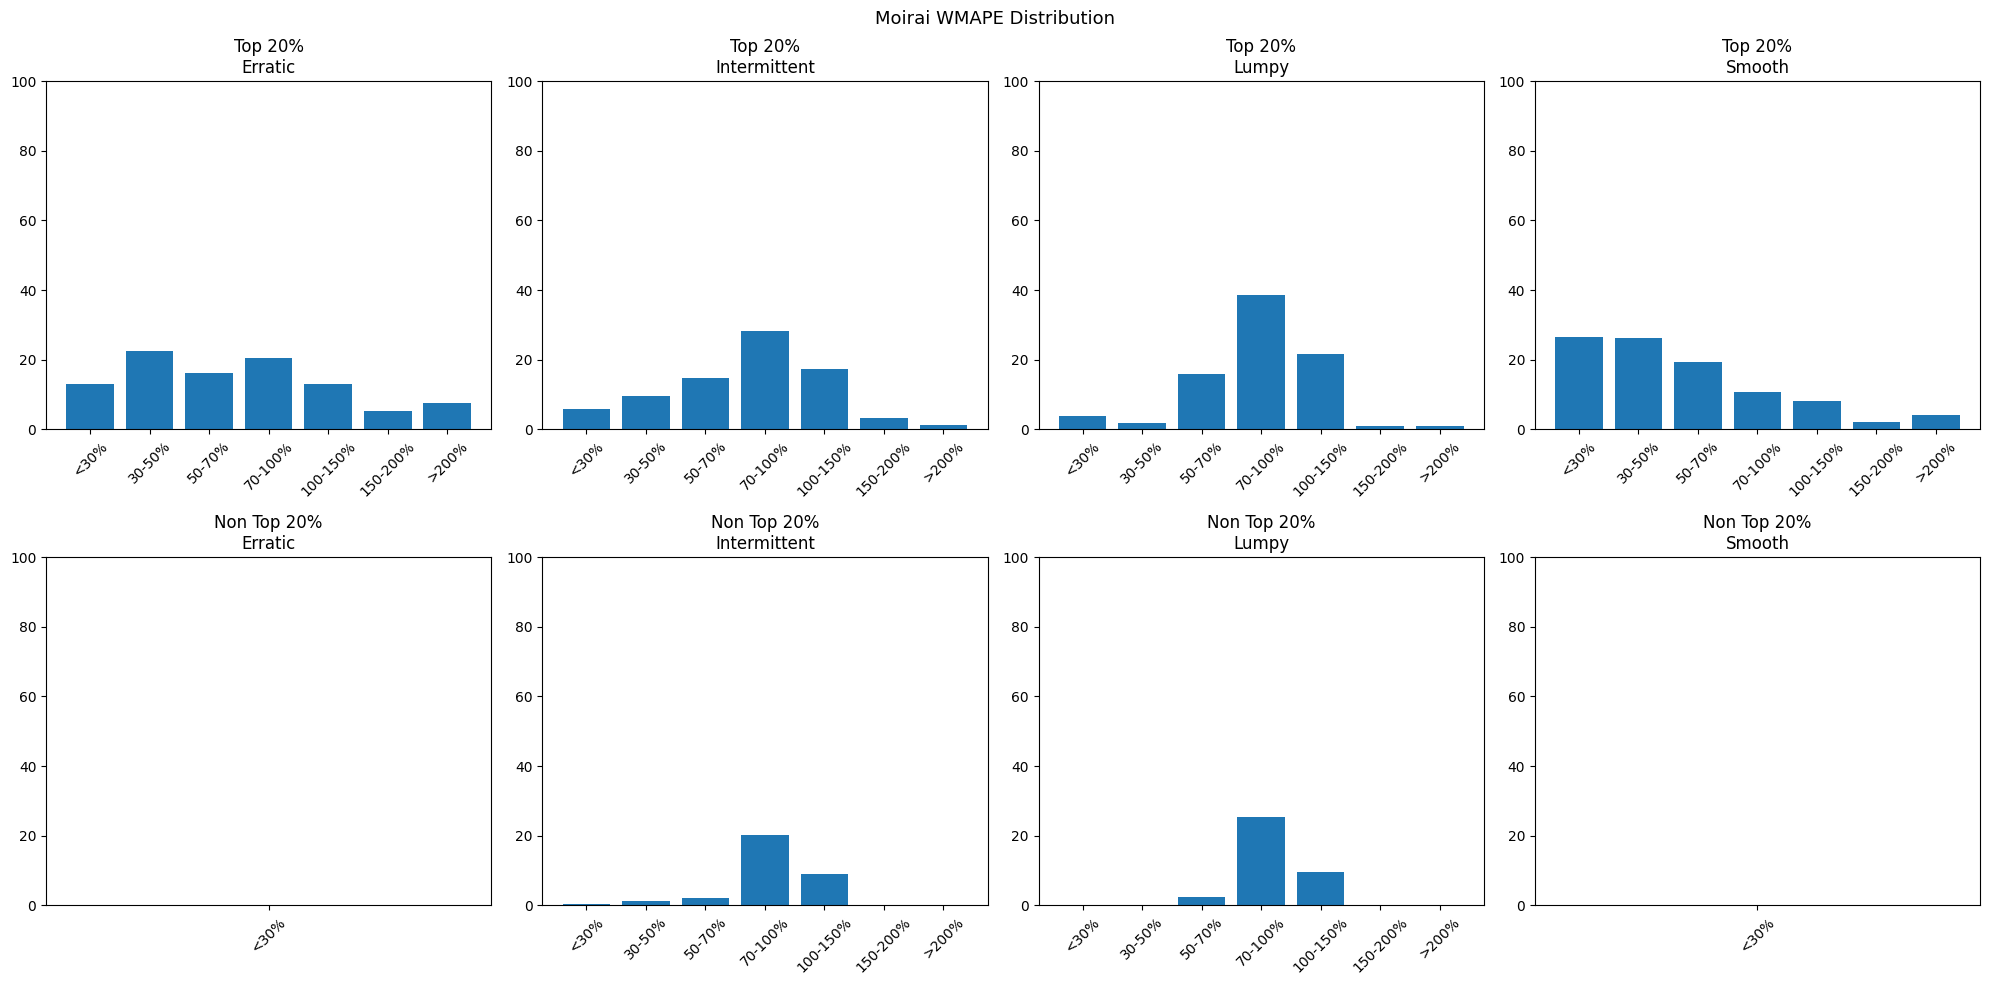

In [103]:
# WMAPE Distribution by Demand Type

demand_types = sorted(
    sku_wmape["demand_type"].dropna().unique()
)

tiers = [
    (1, "Top 20%"),
    (0, "Non Top 20%")
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(20,10)
)

fig.suptitle(
    "Moirai WMAPE Distribution",
    fontsize=13
)

for row_idx, (tier, tier_name) in enumerate(tiers):

    tier_subset = sku_wmape[
        sku_wmape["is_top20pct"] == tier
    ]

    for col_idx, dt in enumerate(demand_types):

        ax = axes[row_idx][col_idx]

        subset = tier_subset[
            tier_subset["demand_type"] == dt
        ]

        band_counts = (
            subset["wmape_band"]
            .value_counts()
            .sort_index()
        )

        band_pct = (
            band_counts
            / len(subset)
            * 100
        ).round(1)

        ax.bar(
            band_counts.index,
            band_pct
        )

        ax.set_ylim(0,100)

        ax.set_title(
            f"{tier_name}\n{dt}"
        )

        ax.tick_params(
            axis="x",
            rotation=45
        )

for c in range(len(demand_types),4):
    axes[0][c].set_visible(False)
    axes[1][c].set_visible(False)

plt.tight_layout()

plt.show()

In [108]:
# Final Summary Report

print("="*60)
print("Moirai Demand Forecasting — Results Summary")
print("="*60)

print("\nScope")
print(f"  Total collision SKUs          : {df['sku_id'].nunique():,}")
print(f"  Total rows                    : {len(df):,}")
print(f"  Forecast horizon              : {N_FORECAST} months")
print(f"  Forecast lag                  : {FORECAST_LAG} months")

print("\nDemand type distribution")

dt_counts = (
    df.groupby("sku_id")["demand_type"]
      .first()
      .value_counts()
)

for dt, n in dt_counts.items():

    print(f"  {dt:<25}: {n:,} SKUs")

print("\nWMAPE comparison (Baseline vs Moirai)")

print(
    f"{'Demand Type':<15}"
    f"{'Baseline':>12}"
    f"{'Moirai':>12}"
    f"{'Improvement':>15}"
)

print("-"*60)

for _, row in summary_df.iterrows():
    print(
        f"{row['demand_type']:<15}"
        f"{row['baseline_wmape']:>12.4f}"
        f"{row['moirai_wmape']:>12.4f}"
        f"{row['improvement_pct']:>14.1f}%"
    )

print("\nSKU-level improvement (>10% WMAPE reduction)")

print(f"  Improved SKUs                 : {len(improved):,}")

top20 = sku_meta["is_top20pct"].sum()
top5 = sku_meta["is_top5pct"].sum()

imp20 = improved["is_top20pct"].sum()
imp5 = improved["is_top5pct"].sum()

print(
    f"  Improved in top 20% SKUs      : "
    f"{imp20:,} of {top20:,} "
    f"({imp20/top20*100:.1f}%)"
)

print(
    f"  Improved in top 5% SKUs       : "
    f"{imp5:,} of {top5:,} "
    f"({imp5/top5*100:.1f}%)"

)

best = summary_df.loc[
    summary_df["improvement_pct"].idxmax()
]

worst = summary_df.loc[
    summary_df["improvement_pct"].idxmin()
]

print("\nKey Findings")

print(
    f"  • Strongest improvement : "
    f"{best['demand_type']} "
    f"({best['improvement_pct']:.1f}%)"
)

print(
    f"  • Weakest performance : "
    f"{worst['demand_type']} "
    f"({worst['improvement_pct']:.1f}%)"
)

print(
    "  • Moirai performs particularly well "
    "for intermittent and lumpy demand "
    "where pretrained temporal representations "
    "capture recurring demand behaviour."
)

print(
    "  • Smooth demand remains difficult "
    "to outperform because the simple "
    "rolling-average baseline is already "
    "highly effective."
)

print("="*60)

Moirai Demand Forecasting — Results Summary

Scope
  Total collision SKUs          : 8,097
  Total rows                    : 180,422
  Forecast horizon              : 18 months
  Forecast lag                  : 3 months

Demand type distribution
  Intermittent             : 6,593 SKUs
  Smooth                   : 972 SKUs
  Lumpy                    : 381 SKUs
  Erratic                  : 124 SKUs
  No demand observed       : 27 SKUs

WMAPE comparison (Baseline vs Moirai)
Demand Type        Baseline      Moirai    Improvement
------------------------------------------------------------
Lumpy                1.3597      0.9029          33.6%
Intermittent         1.4436      0.9933          31.2%
Erratic              0.7635      0.6626          13.2%
Smooth               0.4663      0.5383         -15.4%

SKU-level improvement (>10% WMAPE reduction)
  Improved SKUs                 : 1,281
  Improved in top 20% SKUs      : 752 of 1,635 (46.0%)
  Improved in top 5% SKUs       : 203 of 405 (5

In [106]:
from google.colab import files

files.download("moirai_forecasts_18m.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>